**INSTALL REQUIRED LIBRARIES**

In [ ]:
!pip install kagglehub
!pip install shap lime
!pip install xgboost
!pip install nltk textblob wordcloud
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=345bac797e4d294e57adc8b04789789bec2efa773c10abd894f01cf7cab8cb6b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


**IMPORT ALL LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import zipfile
warnings.filterwarnings('ignore')

# Scikit-learn - ML Models and Utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report,
                            roc_auc_score, roc_curve, cohen_kappa_score,
                            mean_squared_error, mean_absolute_error, r2_score)

# Classification Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                             BaggingClassifier, AdaBoostClassifier)
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# XGBoost
import xgboost as xgb

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
import re
import string

# Model Interpretability
import shap
import lime
from lime.lime_text import LimeTextExplainer
from lime.lime_tabular import LimeTabularExplainer

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')

# Create folder for saving images
if not os.path.exists('project_images'):
    os.makedirs('project_images')

print("All libraries imported successfully!")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


All libraries imported successfully!


**DOWNLOAD DATASETS FROM KAGGLE**

In [ ]:
import kagglehub

# Dataset 1: Amazon Product Reviews (TEXT DATA) - Member 1
print("Downloading Amazon Product Reviews Dataset...")
amazon_reviews_path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
print("Path to Amazon Reviews:", amazon_reviews_path)



100%|██████████| 242M/242M [00:04<00:00, 61.5MB/s]

Extracting files...


Path to Amazon Reviews: /root/.cache/kagglehub/datasets/snap/amazon-fine-food-reviews/versions/2


In [ ]:
 #List files in the directory
amazon_files = os.listdir(amazon_reviews_path)
print("Amazon Reviews files:", amazon_files)

# Find the CSV or SQLite file
review_file = None
for f in amazon_files:
    if f.endswith('.csv'):
        review_file = f
        break

if review_file:
    print("Loading:", review_file)
    amazon_df = pd.read_csv(f"{amazon_reviews_path}/{review_file}", on_bad_lines='skip', engine='python')
else:
    # Try SQLite if no CSV
    import sqlite3
    for f in amazon_files:
        if f.endswith('.sqlite') or f.endswith('.db'):
            conn = sqlite3.connect(f"{amazon_reviews_path}/{f}")
            amazon_df = pd.read_sql_query("SELECT * FROM Reviews", conn)
            conn.close()
            print("Loaded from SQLite database")
            break

print("\nAmazon Reviews Dataset Shape:", amazon_df.shape)
print("Columns:", amazon_df.columns.tolist())

Amazon Reviews files: ['hashes.txt', 'Reviews.csv', 'database.sqlite']
Loading: Reviews.csv

Amazon Reviews Dataset Shape: (568454, 10)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


**EXPLORATORY DATA ANALYSIS (EDA)**


Dataset Shape: (568454, 10)

Column Data Types:
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

First 5 rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0        

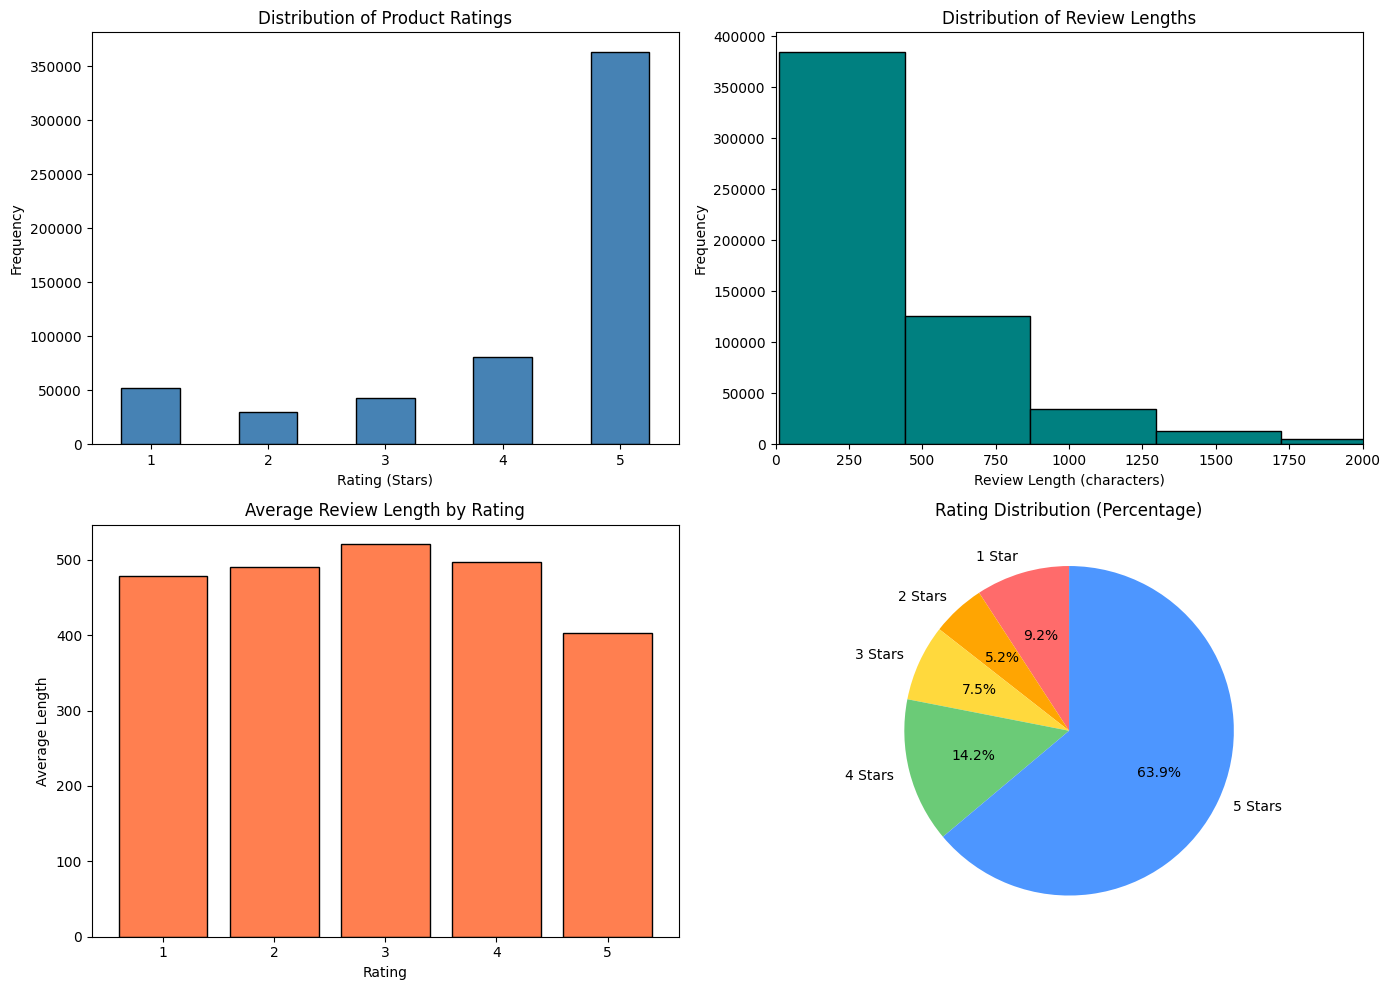

In [ ]:
# Basic info
print("\nDataset Shape:", amazon_df.shape)
print("\nColumn Data Types:")
print(amazon_df.dtypes)

print("\nFirst 5 rows:")
print(amazon_df.head())

# Check for missing values
print("\nMissing Values:")
print(amazon_df.isnull().sum())

# Identify text and rating columns
# Common column names in Amazon reviews datasets
text_col = None
rating_col = None

for col in amazon_df.columns:
    col_lower = col.lower()
    if 'text' in col_lower or 'review' in col_lower:
        if amazon_df[col].dtype == 'object':
            text_col = col
    if 'score' in col_lower or 'rating' in col_lower or 'star' in col_lower:
        rating_col = col

print("\nIdentified columns:")
print("Text column:", text_col)
print("Rating column:", rating_col)

# If columns not found, use first text and numeric columns
if text_col is None:
    for col in amazon_df.columns:
        if amazon_df[col].dtype == 'object' and amazon_df[col].str.len().mean() > 50:
            text_col = col
            break

if rating_col is None:
    for col in amazon_df.columns:
        if amazon_df[col].dtype in ['int64', 'float64']:
            if amazon_df[col].min() >= 1 and amazon_df[col].max() <= 5:
                rating_col = col
                break

print("\nFinal columns selected:")
print("Text column:", text_col)
print("Rating column:", rating_col)

# Fix data types
amazon_df[rating_col] = pd.to_numeric(amazon_df[rating_col], errors='coerce')
amazon_df = amazon_df.dropna(subset=[text_col, rating_col])
amazon_df[rating_col] = amazon_df[rating_col].astype(int)
amazon_df[text_col] = amazon_df[text_col].astype(str)

print("\nRating Distribution:")
print(amazon_df[rating_col].value_counts().sort_index())

# Create review length column
amazon_df['review_length'] = amazon_df[text_col].apply(len)

print("\nStatistical Summary:")
print(amazon_df.describe())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating distribution
amazon_df[rating_col].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Product Ratings', fontsize=12)
axes[0, 0].set_xlabel('Rating (Stars)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xticklabels(['1', '2', '3', '4', '5'], rotation=0)

# Review length distribution
axes[0, 1].hist(amazon_df['review_length'], bins=50, edgecolor='black', color='teal')
axes[0, 1].set_title('Distribution of Review Lengths', fontsize=12)
axes[0, 1].set_xlabel('Review Length (characters)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim(0, 2000)

# Average review length by rating
avg_length_by_rating = amazon_df.groupby(rating_col)['review_length'].mean()
axes[1, 0].bar(avg_length_by_rating.index, avg_length_by_rating.values, color='coral', edgecolor='black')
axes[1, 0].set_title('Average Review Length by Rating', fontsize=12)
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Average Length')

# Rating percentage pie chart
rating_counts = amazon_df[rating_col].value_counts().sort_index()
colors = ['#ff6b6b', '#ffa502', '#ffd93d', '#6bcb77', '#4d96ff']
axes[1, 1].pie(rating_counts.values, labels=['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars'],
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 1].set_title('Rating Distribution (Percentage)', fontsize=12)

plt.tight_layout()
plt.savefig('project_images/member1_eda.png', dpi=300, bbox_inches='tight')
plt.show()



DATA PREPROCESSING

In [ ]:
# Create a copy for preprocessing
amazon_processed = amazon_df.copy()

# Create sentiment labels from ratings
# Rating 1-2: Negative (0), 3: Neutral (1), 4-5: Positive (2)
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

amazon_processed['sentiment'] = amazon_processed[rating_col].apply(rating_to_sentiment)

print("\nSentiment Distribution:")
print(amazon_processed['sentiment'].value_counts())
print("0: Negative, 1: Neutral, 2: Positive")

# Text preprocessing function
def preprocess_text(text):
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    try:
        tokens = word_tokenize(text)
    except:
        tokens = text.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Remove short words
    tokens = [token for token in tokens if len(token) > 2]

    return ' '.join(tokens)

# Sample for faster processing
print("\nSampling and preprocessing text...")
sample_size = min(50000, len(amazon_processed))
amazon_sample = amazon_processed.sample(n=sample_size, random_state=42).copy()

# Apply preprocessing
amazon_sample['cleaned_review'] = amazon_sample[text_col].apply(preprocess_text)

# Remove empty reviews
amazon_sample = amazon_sample[amazon_sample['cleaned_review'].str.len() > 0]

print("Preprocessed", len(amazon_sample), "reviews")

# Show example
print("\nExample - Original vs Cleaned:")
print("Original:", amazon_sample[text_col].iloc[0][:200], "...")
print("\nCleaned:", amazon_sample['cleaned_review'].iloc[0][:200], "...")


Sentiment Distribution:
sentiment
2    443777
0     82037
1     42640
Name: count, dtype: int64
0: Negative, 1: Neutral, 2: Positive

Sampling and preprocessing text...
Preprocessed 50000 reviews

Example - Original vs Cleaned:
Original: Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  S ...

Cleaned: tried couple brand glutenfree sandwich cooky best bunch theyre crunchy true texture real cooky arent glutenfree might think filling make bit sweet mean ive satisfied sweet tooth sooner chocolate versi ...


FEATURE EXTRACTION (TF-IDF)

In [ ]:
# Split data
X_text = amazon_sample['cleaned_review']
y_text = amazon_sample['sentiment']
#train test split 75-25
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text, test_size=0.25, random_state=42, stratify=y_text
)

print("Training set:", len(X_train_text), "samples")
print("Test set:", len(X_test_text), "samples")

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    stop_words='english'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("\nTF-IDF Matrix Shape:")
print("Training:", X_train_tfidf.shape)
print("Test:", X_test_tfidf.shape)

# Show top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nSample features:", list(feature_names[:20]))

print("\nTF-IDF Feature Extraction Complete!")

Training set: 37500 samples
Test set: 12500 samples

TF-IDF Matrix Shape:
Training: (37500, 5000)
Test: (12500, 5000)

Sample features: ['ability', 'able', 'able buy', 'able eat', 'able make', 'able purchase', 'absolute', 'absolute favorite', 'absolutely', 'absolutely best', 'absolutely delicious', 'absolutely love', 'absolutely loved', 'absorb', 'acai', 'acceptable', 'access', 'accident', 'accidentally', 'according']

TF-IDF Feature Extraction Complete!


MODEL 1: NAIVE BAYES CLASSIFIER


5-Fold Cross-Validation Accuracy: 0.8134 (+/- 0.0014 )

NAIVE BAYES - PERFORMANCE METRICS:
----------------------------------------
Accuracy: 0.813
Precision (weighted): 0.7508
Recall (weighted): 0.813
F1-Score (weighted): 0.754
Cohen's Kappa: 0.2403

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.25      0.38      1776
     Neutral       0.00      0.00      0.00       948
    Positive       0.81      0.99      0.89      9776

    accuracy                           0.81     12500
   macro avg       0.54      0.41      0.43     12500
weighted avg       0.75      0.81      0.75     12500



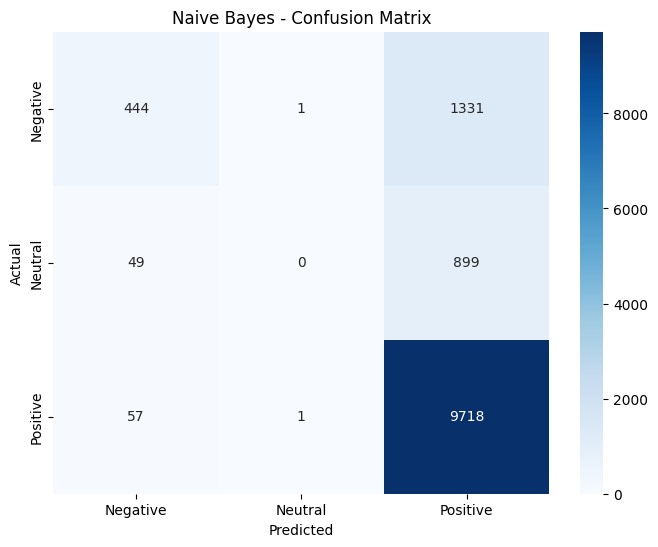

In [ ]:
# Train Multinomial Naive Bayes
nb_classifier = MultinomialNB(alpha=1.0)

# Cross-validation
cv_scores_nb = cross_val_score(nb_classifier, X_train_tfidf, y_train_text, cv=5, scoring='accuracy')
print("\n5-Fold Cross-Validation Accuracy:", round(cv_scores_nb.mean(), 4),
      "(+/-", round(cv_scores_nb.std()*2, 4), ")")

# Train on full training set
nb_classifier.fit(X_train_tfidf, y_train_text)

# Predictions
y_pred_nb = nb_classifier.predict(X_test_tfidf)
y_pred_proba_nb = nb_classifier.predict_proba(X_test_tfidf)

# Evaluation Metrics
print("\nNAIVE BAYES - PERFORMANCE METRICS:")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test_text, y_pred_nb), 4))
print("Precision (weighted):", round(precision_score(y_test_text, y_pred_nb, average='weighted'), 4))
print("Recall (weighted):", round(recall_score(y_test_text, y_pred_nb, average='weighted'), 4))
print("F1-Score (weighted):", round(f1_score(y_test_text, y_pred_nb, average='weighted'), 4))
print("Cohen's Kappa:", round(cohen_kappa_score(y_test_text, y_pred_nb), 4))

print("\nClassification Report:")
print(classification_report(y_test_text, y_pred_nb, target_names=['Negative', 'Neutral', 'Positive']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test_text, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('project_images/member1_nb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Store results
member1_results = {
    'Naive Bayes': {
        'Accuracy': accuracy_score(y_test_text, y_pred_nb),
        'Precision': precision_score(y_test_text, y_pred_nb, average='weighted'),
        'Recall': recall_score(y_test_text, y_pred_nb, average='weighted'),
        'F1-Score': f1_score(y_test_text, y_pred_nb, average='weighted'),
        'Cohen_Kappa': cohen_kappa_score(y_test_text, y_pred_nb)
    }
}

In [ ]:
#SUPPORT VECTOR MACHINE (SVM) - MOdel 2


5-Fold Cross-Validation Accuracy: 0.8467 (+/- 0.0052 )

SVM - PERFORMANCE METRICS:
----------------------------------------
Accuracy: 0.8456
Precision (weighted): 0.8174
Recall (weighted): 0.8456
F1-Score (weighted): 0.8242
Cohen's Kappa: 0.5106

Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.61      0.64      1776
     Neutral       0.41      0.12      0.19       948
    Positive       0.88      0.96      0.92      9776

    accuracy                           0.85     12500
   macro avg       0.66      0.56      0.58     12500
weighted avg       0.82      0.85      0.82     12500



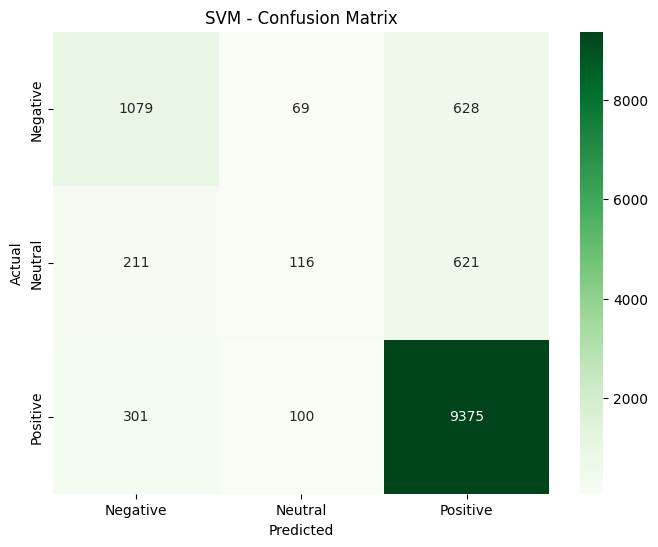

In [ ]:
# Train SVM with Linear kernel
svm_classifier = LinearSVC(C=1.0, max_iter=2000, random_state=42)

# Cross-validation
cv_scores_svm = cross_val_score(svm_classifier, X_train_tfidf, y_train_text, cv=5, scoring='accuracy')
print("\n5-Fold Cross-Validation Accuracy:", round(cv_scores_svm.mean(), 4),
      "(+/-", round(cv_scores_svm.std()*2, 4), ")")

# Train on full training set
svm_classifier.fit(X_train_tfidf, y_train_text)

# Predictions
y_pred_svm = svm_classifier.predict(X_test_tfidf)

# Evaluation Metrics
print("\nSVM - PERFORMANCE METRICS:")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test_text, y_pred_svm), 4))
print("Precision (weighted):", round(precision_score(y_test_text, y_pred_svm, average='weighted'), 4))
print("Recall (weighted):", round(recall_score(y_test_text, y_pred_svm, average='weighted'), 4))
print("F1-Score (weighted):", round(f1_score(y_test_text, y_pred_svm, average='weighted'), 4))
print("Cohen's Kappa:", round(cohen_kappa_score(y_test_text, y_pred_svm), 4))

print("\nClassification Report:")
print(classification_report(y_test_text, y_pred_svm, target_names=['Negative', 'Neutral', 'Positive']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test_text, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('project_images/member1_svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Store results
member1_results['SVM'] = {
    'Accuracy': accuracy_score(y_test_text, y_pred_svm),
    'Precision': precision_score(y_test_text, y_pred_svm, average='weighted'),
    'Recall': recall_score(y_test_text, y_pred_svm, average='weighted'),
    'F1-Score': f1_score(y_test_text, y_pred_svm, average='weighted'),
    'Cohen_Kappa': cohen_kappa_score(y_test_text, y_pred_svm)
}

MODEL INTERPRETABILITY (LIME)


LIME Explanations for Sample Reviews:
--------------------------------------------------

Review 0 :
Text: product really taste like plastic raisin deeply disappointed recommend product anyone ...
True Label: Negative
Predicted: Positive

Top features influencing prediction:
  ' recommend ': -0.0555 -> Negative
  ' really ': 0.0266 -> Positive
  ' disappointed ': 0.0208 -> Positive
  ' product ': -0.0191 -> Negative
  ' taste ': 0.0133 -> Positive

Review 50 :
Text: buying ever yuck yuck yuck might well roasted straw ...
True Label: Negative
Predicted: Negative

Top features influencing prediction:
  ' straw ': 0.0454 -> Positive
  ' yuck ': -0.0378 -> Negative
  ' buying ': -0.008 -> Negative
  ' roasted ': -0.0042 -> Negative
  ' well ': 0.0031 -> Positive

Review 100 :
Text: new raising kitten tried variety canned food recent month although kitten readily took fancy feast brand healthy food biggest concern byproduct conten ...
True Label: Positive
Predicted: Positive

Top features 

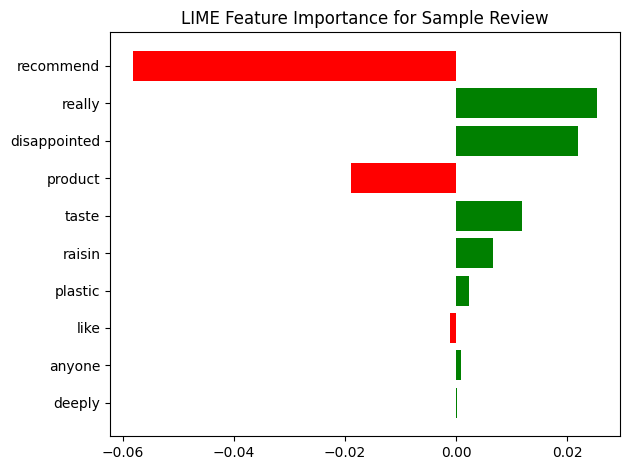

LIME explanation saved!

Member 1 LIME Interpretability Complete!


In [ ]:
# Create LIME explainer for text
class_names = ['Negative', 'Neutral', 'Positive']

# Create a pipeline function for LIME
def predict_proba_pipeline(texts):
    tfidf_texts = tfidf_vectorizer.transform(texts)
    return nb_classifier.predict_proba(tfidf_texts)

# Initialize LIME Text Explainer
lime_explainer = LimeTextExplainer(class_names=class_names, random_state=42)

# Explain sample predictions
print("\nLIME Explanations for Sample Reviews:")
print("-" * 50)

# Get sample indices
sample_indices = [0, 50, 100]

for idx in sample_indices[:3]:
    if idx < len(X_test_text):
        review_text = X_test_text.iloc[idx]
        true_label = y_test_text.iloc[idx]
        predicted_label = y_pred_nb[idx]

        print("\nReview", idx, ":")
        print("Text:", review_text[:150], "...")
        print("True Label:", class_names[true_label])
        print("Predicted:", class_names[predicted_label])

        # Generate LIME explanation
        try:
            exp = lime_explainer.explain_instance(
                review_text,
                predict_proba_pipeline,
                num_features=10,
                num_samples=500
            )

            print("\nTop features influencing prediction:")
            for feature, weight in exp.as_list()[:5]:
                direction = "-> Positive" if weight > 0 else "-> Negative"
                print("  '", feature, "':", round(weight, 4), direction)
        except Exception as e:
            print("Could not generate LIME explanation:", str(e))

# Generate and save LIME visualization
print("\nGenerating LIME visualization...")
try:
    exp = lime_explainer.explain_instance(
        X_test_text.iloc[0],
        predict_proba_pipeline,
        num_features=10
    )

    fig = exp.as_pyplot_figure()
    plt.title('LIME Feature Importance for Sample Review')
    plt.tight_layout()
    plt.savefig('project_images/member1_lime_features.png', dpi=300, bbox_inches='tight')
    plt.show()

    exp.save_to_file('project_images/member1_lime_explanation.html')
    print("LIME explanation saved!")
except Exception as e:
    print("Error generating LIME visualization:", str(e))

print("\nMember 1 LIME Interpretability Complete!")

MODEL COMPARISON


Model Performance Comparison:
             Accuracy  Precision   Recall  F1-Score  Cohen_Kappa
Naive Bayes   0.81296   0.750808  0.81296  0.753952     0.240271
SVM           0.84560   0.817361  0.84560  0.824156     0.510589


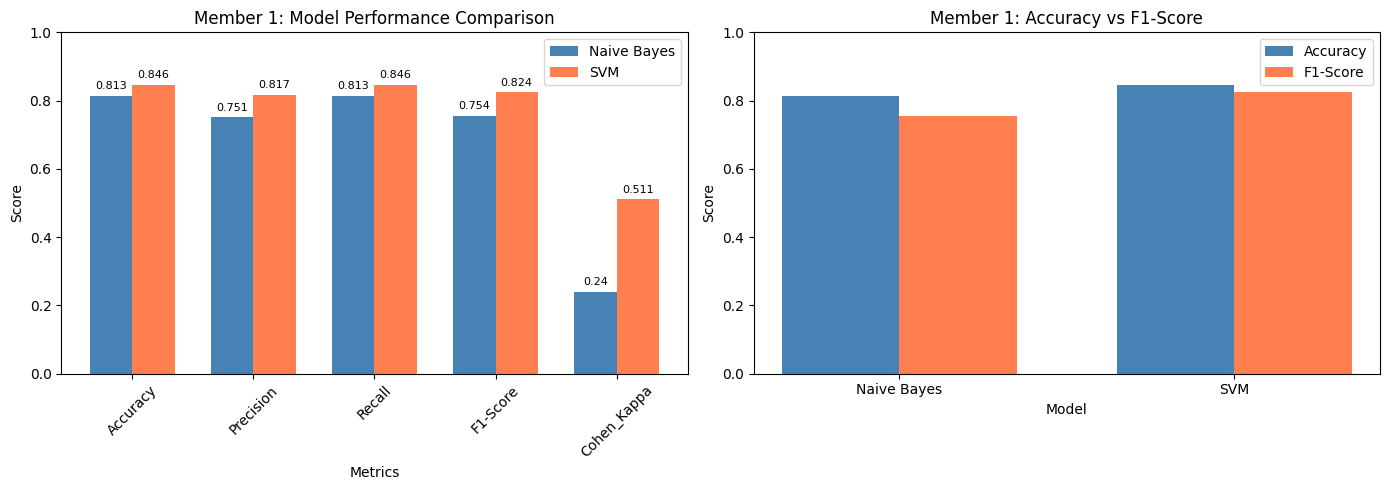

In [ ]:
# Create comparison dataframe
comparison_df = pd.DataFrame(member1_results).T
print("\nModel Performance Comparison:")
print(comparison_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Cohen_Kappa']
x = np.arange(len(metrics))
width = 0.35

nb_scores = [member1_results['Naive Bayes'][m] for m in metrics]
svm_scores = [member1_results['SVM'][m] for m in metrics]

axes[0].bar(x - width/2, nb_scores, width, label='Naive Bayes', color='steelblue')
axes[0].bar(x + width/2, svm_scores, width, label='SVM', color='coral')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Member 1: Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Add value labels
for i, (nb_val, svm_val) in enumerate(zip(nb_scores, svm_scores)):
    axes[0].text(i - width/2, nb_val + 0.02, str(round(nb_val, 3)), ha='center', fontsize=8)
    axes[0].text(i + width/2, svm_val + 0.02, str(round(svm_val, 3)), ha='center', fontsize=8)

# Accuracy vs F1 comparison
model_names = ['Naive Bayes', 'SVM']
accuracies = [member1_results['Naive Bayes']['Accuracy'], member1_results['SVM']['Accuracy']]
f1_scores_list = [member1_results['Naive Bayes']['F1-Score'], member1_results['SVM']['F1-Score']]

x_pos = np.arange(len(model_names))
axes[1].bar(x_pos - width/2, accuracies, width, label='Accuracy', color='steelblue')
axes[1].bar(x_pos + width/2, f1_scores_list, width, label='F1-Score', color='coral')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_title('Member 1: Accuracy vs F1-Score')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names)
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('project_images/member1_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results to CSV
comparison_df.to_csv('project_images/member1_results.csv')

LOAD E-COMMERCE CHURN DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, cohen_kappa_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
try:
    import kagglehub
    path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")
    print(f"Dataset downloaded to: {path}")

    import os
    for file in os.listdir(path):
        if file.endswith('.csv'):
            churn_df = pd.read_csv(os.path.join(path, file))
            print(f"Loaded: {file}")
            break
except:
    # Method 2: Direct URL (backup)
    print("Trying alternative download method...")
    url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/main/Churn_Modelling.csv"
    churn_df = pd.read_csv(url)

print(f"\nDataset Shape: {churn_df.shape}")
print(f"Columns: {churn_df.columns.tolist()}")

100%|██████████| 262k/262k [00:00<00:00, 59.2MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/shantanudhakadd/bank-customer-churn-prediction/versions/1
Loaded: Churn_Modelling.csv

Dataset Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


EXPLORATORY DATA ANALYSIS (EDA)

DATA UNDERSTANDING PHASE (CRISP-DM)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Target Variable Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


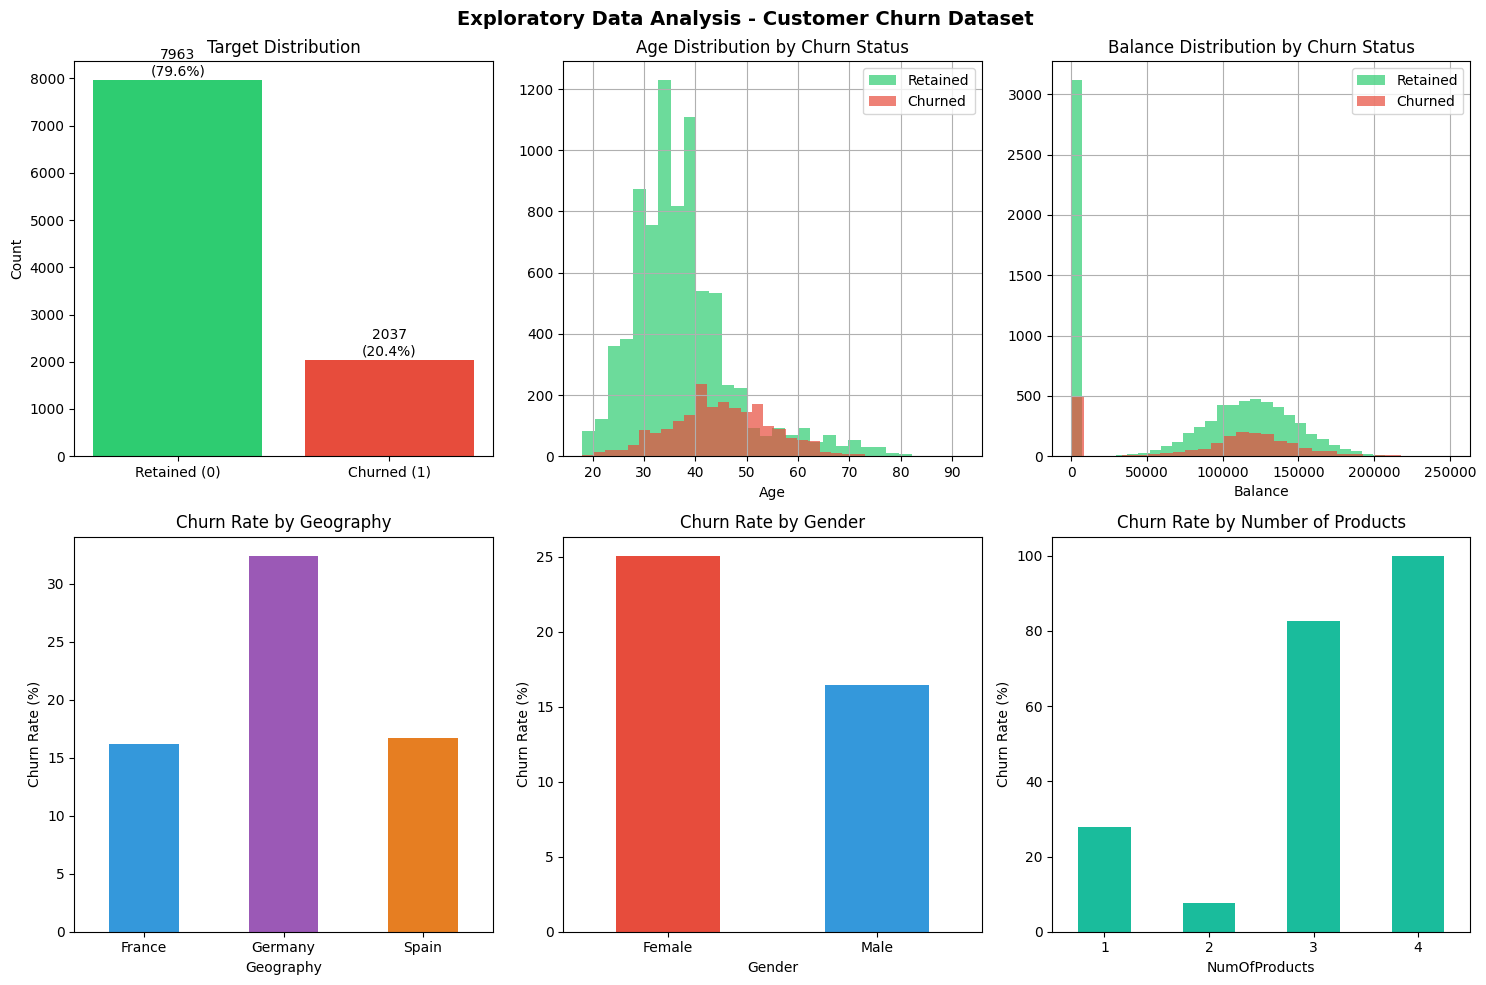

EDA figure saved as 'member2_eda.png'


In [ ]:
print("DATA UNDERSTANDING PHASE (CRISP-DM)")
print("=" * 60)

print("\nFirst 5 rows:")
display(churn_df.head())

print("\nDataset Info:")
print(churn_df.info())

print("\nStatistical Summary:")
display(churn_df.describe())

print("\nMissing Values:")
print(churn_df.isnull().sum())

print("\nTarget Variable Distribution:")
print(churn_df['Exited'].value_counts())
print(f"\nChurn Rate: {churn_df['Exited'].mean()*100:.2f}%")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Customer Churn Dataset', fontsize=14, fontweight='bold')

# 1. Target Distribution
ax1 = axes[0, 0]
colors = ['#2ecc71', '#e74c3c']
churn_counts = churn_df['Exited'].value_counts()
ax1.bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=colors)
ax1.set_title('Target Distribution')
ax1.set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    ax1.text(i, v + 100, f'{v}\n({v/len(churn_df)*100:.1f}%)', ha='center')

# 2. Age Distribution by Churn
ax2 = axes[0, 1]
churn_df[churn_df['Exited']==0]['Age'].hist(alpha=0.7, label='Retained', bins=30, ax=ax2, color='#2ecc71')
churn_df[churn_df['Exited']==1]['Age'].hist(alpha=0.7, label='Churned', bins=30, ax=ax2, color='#e74c3c')
ax2.set_title('Age Distribution by Churn Status')
ax2.set_xlabel('Age')
ax2.legend()

# 3. Balance Distribution
ax3 = axes[0, 2]
churn_df[churn_df['Exited']==0]['Balance'].hist(alpha=0.7, label='Retained', bins=30, ax=ax3, color='#2ecc71')
churn_df[churn_df['Exited']==1]['Balance'].hist(alpha=0.7, label='Churned', bins=30, ax=ax3, color='#e74c3c')
ax3.set_title('Balance Distribution by Churn Status')
ax3.set_xlabel('Balance')
ax3.legend()

# 4. Geography vs Churn
ax4 = axes[1, 0]
geo_churn = churn_df.groupby('Geography')['Exited'].mean() * 100
geo_churn.plot(kind='bar', ax=ax4, color=['#3498db', '#9b59b6', '#e67e22'])
ax4.set_title('Churn Rate by Geography')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

# 5. Gender vs Churn
ax5 = axes[1, 1]
gender_churn = churn_df.groupby('Gender')['Exited'].mean() * 100
gender_churn.plot(kind='bar', ax=ax5, color=['#e74c3c', '#3498db'])
ax5.set_title('Churn Rate by Gender')
ax5.set_ylabel('Churn Rate (%)')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=0)

# 6. Number of Products vs Churn
ax6 = axes[1, 2]
prod_churn = churn_df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', ax=ax6, color='#1abc9c')
ax6.set_title('Churn Rate by Number of Products')
ax6.set_ylabel('Churn Rate (%)')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('member2_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("EDA figure saved as 'member2_eda.png'")

CORRELATION ANALYSIS

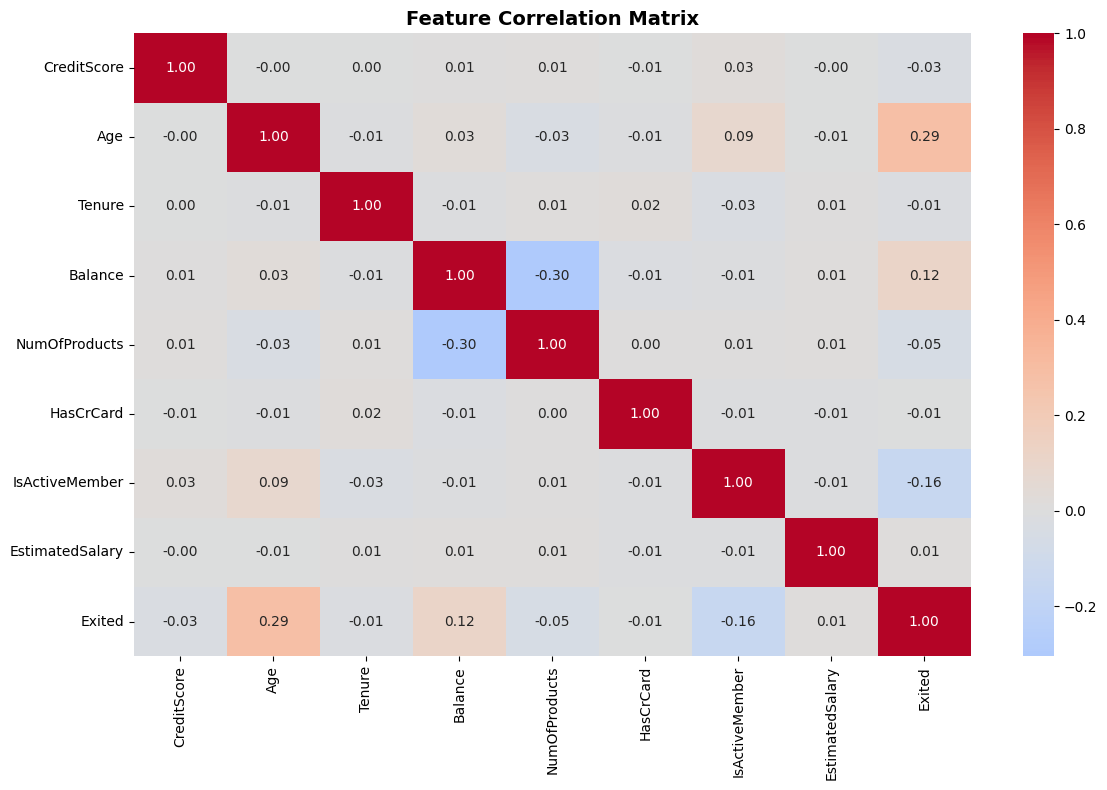


Correlation with Target (Exited):
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


In [ ]:
# Select numeric columns for correlation
numeric_cols = churn_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['RowNumber', 'CustomerId']]

plt.figure(figsize=(12, 8))
correlation_matrix = churn_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('member2_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation with Target (Exited):")
print(correlation_matrix['Exited'].sort_values(ascending=False))

DATA PREPARATION (CRISP-DM)

In [ ]:
print("DATA PREPARATION PHASE (CRISP-DM)")
print("=" * 60)

# Create a copy for processing
df = churn_df.copy()

# Remove unnecessary columns
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=columns_to_drop, errors='ignore')
print(f"\nDropped columns: {columns_to_drop}")

# Encode categorical variables
label_encoders = {}
categorical_cols = ['Geography', 'Gender']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nProcessed DataFrame shape: {df.shape}")
print(f"Features: {df.columns.tolist()}")


DATA PREPARATION PHASE (CRISP-DM)

Dropped columns: ['RowNumber', 'CustomerId', 'Surname']
Encoded Geography: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Encoded Gender: {'Female': np.int64(0), 'Male': np.int64(1)}

Processed DataFrame shape: (10000, 11)
Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


FEATURE AND TARGET SPLIT

In [ ]:
# Define features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {X.columns.tolist()}")

# Train-test split (75-25 as per assignment)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining set churn rate: {y_train.mean()*100:.2f}%")
print(f"Testing set churn rate: {y_test.mean()*100:.2f}%")

Features shape: (10000, 10)
Target shape: (10000,)

Feature names: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Training set: 7500 samples
Testing set: 2500 samples

Training set churn rate: 20.37%
Testing set churn rate: 20.36%


FEATURE SCALING

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Features scaled using StandardScaler")
print(f"Scaled training set shape: {X_train_scaled.shape}")

Features scaled using StandardScaler
Scaled training set shape: (7500, 10)


HANDLE CLASS IMBALANCE WITH SMOTE

In [ ]:
print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print(f"\nTraining samples increased from {len(X_train)} to {len(X_train_smote)}")



Class distribution before SMOTE:
Exited
0    5972
1    1528
Name: count, dtype: int64

Class distribution after SMOTE:
Exited
1    5972
0    5972
Name: count, dtype: int64

Training samples increased from 7500 to 11944


MODEL 1 - RANDOM FOREST

In [ ]:
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("=" * 60)

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
print("\nTraining Random Forest...")
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
print("\nRandom Forest Results:")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_prob):.4f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_test, rf_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Retained', 'Churned']))


MODEL 1: RANDOM FOREST CLASSIFIER

Training Random Forest...

Random Forest Results:
----------------------------------------
Accuracy:  0.8276
Precision: 0.5629
Recall:    0.6857
F1-Score:  0.6182
ROC-AUC:   0.8648
Cohen's Kappa: 0.5083

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.86      0.89      1991
     Churned       0.56      0.69      0.62       509

    accuracy                           0.83      2500
   macro avg       0.74      0.77      0.75      2500
weighted avg       0.84      0.83      0.83      2500



MODEL 2 - XGBOOST

In [ ]:
print("MODEL 2: XGBOOST CLASSIFIER")
print("=" * 60)

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
print("\nTraining XGBoost...")
xgb_model.fit(X_train_smote, y_train_smote)

# Predictions
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
print("\nXGBoost Results:")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, xgb_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_test, xgb_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Retained', 'Churned']))

MODEL 2: XGBOOST CLASSIFIER

Training XGBoost...

XGBoost Results:
----------------------------------------
Accuracy:  0.8516
Precision: 0.6348
Recall:    0.6385
F1-Score:  0.6366
ROC-AUC:   0.8714
Cohen's Kappa: 0.5434

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.91      0.91      1991
     Churned       0.63      0.64      0.64       509

    accuracy                           0.85      2500
   macro avg       0.77      0.77      0.77      2500
weighted avg       0.85      0.85      0.85      2500



MODEL COMPARISON

In [ ]:
print("MODEL COMPARISON")
print("=" * 60)

# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)],
    'Recall': [recall_score(y_test, rf_pred), recall_score(y_test, xgb_pred)],
    'F1-Score': [f1_score(y_test, rf_pred), f1_score(y_test, xgb_pred)],
    'ROC-AUC': [roc_auc_score(y_test, rf_prob), roc_auc_score(y_test, xgb_prob)],
    'Cohen Kappa': [cohen_kappa_score(y_test, rf_pred), cohen_kappa_score(y_test, xgb_pred)]
})

print("\nModel Comparison Summary:")
display(results)

# Identify best model
best_model = results.loc[results['ROC-AUC'].idxmax(), 'Model']
print(f"\nBest Model (by ROC-AUC): {best_model}")

MODEL COMPARISON

Model Comparison Summary:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Cohen Kappa
0,Random Forest,0.8276,0.562903,0.685658,0.618246,0.864811,0.508292
1,XGBoost,0.8516,0.634766,0.638507,0.636631,0.871414,0.543392



Best Model (by ROC-AUC): XGBoost


VISUALIZATION - MODEL COMPARISON

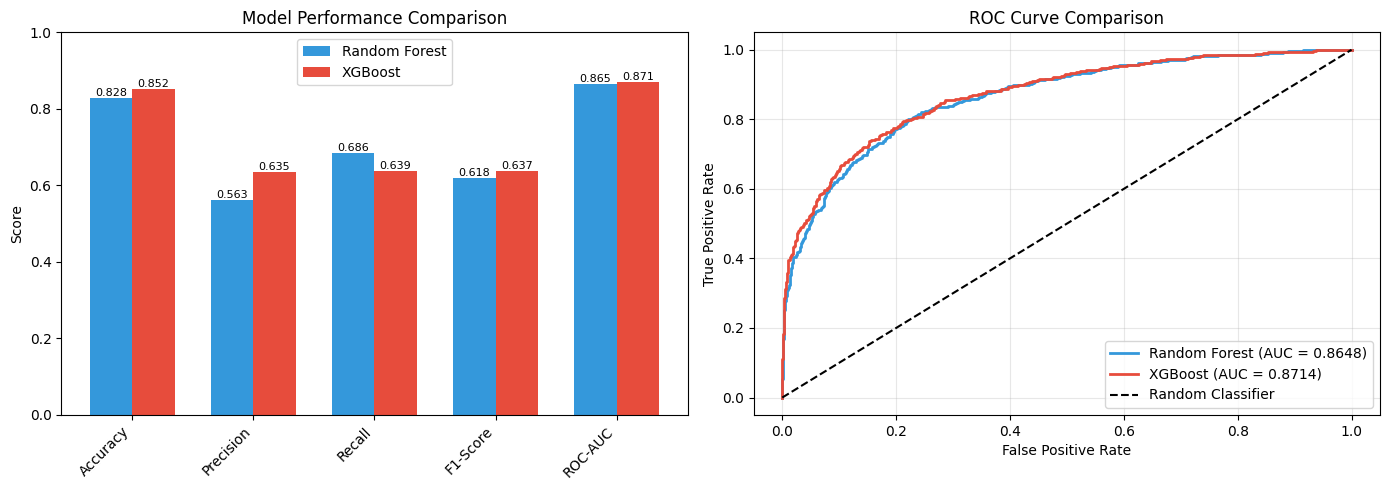

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Performance Metrics Comparison
ax1 = axes[0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

rf_scores = [results.loc[0, m] for m in metrics]
xgb_scores = [results.loc[1, m] for m in metrics]

bars1 = ax1.bar(x - width/2, rf_scores, width, label='Random Forest', color='#3498db')
bars2 = ax1.bar(x + width/2, xgb_scores, width, label='XGBoost', color='#e74c3c')

ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
             ha='center', va='bottom', fontsize=8)

# Plot 2: ROC Curves
ax2 = axes[1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

ax2.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})', color='#3498db', linewidth=2)
ax2.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.4f})', color='#e74c3c', linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve Comparison')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('member2_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# FEATURE IMPORTANCE - RANDOM FOREST

CONFUSION MATRICES

FEATURE IMPORTANCE ANALYSIS

Random Forest Feature Importance:


,Feature,Importance
3,Age,0.335075
6,NumOfProducts,0.237825
5,Balance,0.106782
1,Geography,0.095414
8,IsActiveMember,0.053217
4,Tenure,0.049529
9,EstimatedSalary,0.047890
0,CreditScore,0.046129
2,Gender,0.020726
7,HasCrCard,0.007412



XGBoost Feature Importance:


,Feature,Importance
6,NumOfProducts,0.293014
3,Age,0.161845
8,IsActiveMember,0.140880
1,Geography,0.133822
4,Tenure,0.091145
5,Balance,0.060576
2,Gender,0.051892
9,EstimatedSalary,0.023678
0,CreditScore,0.023268
7,HasCrCard,0.019881


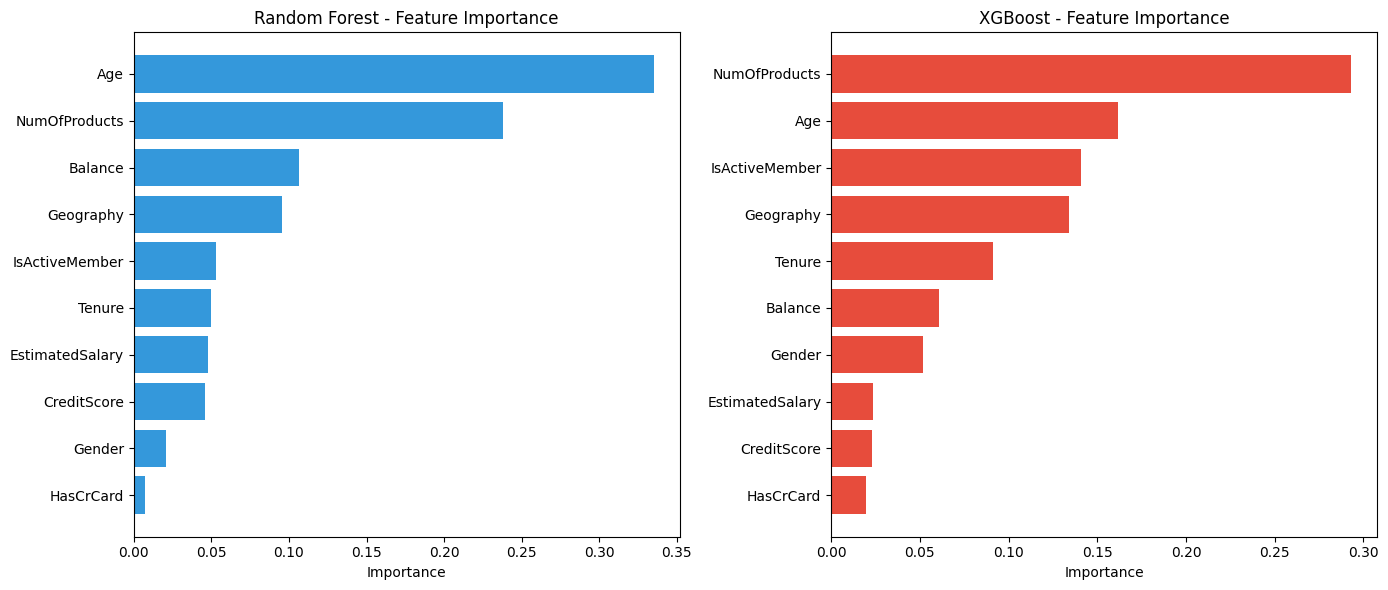

In [ ]:
print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
display(rf_importance)

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nXGBoost Feature Importance:")
display(xgb_importance)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='#3498db')
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest - Feature Importance')
axes[0].invert_yaxis()

# XGBoost
axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color='#e74c3c')
axes[1].set_xlabel('Importance')
axes[1].set_title('XGBoost - Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('member2_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


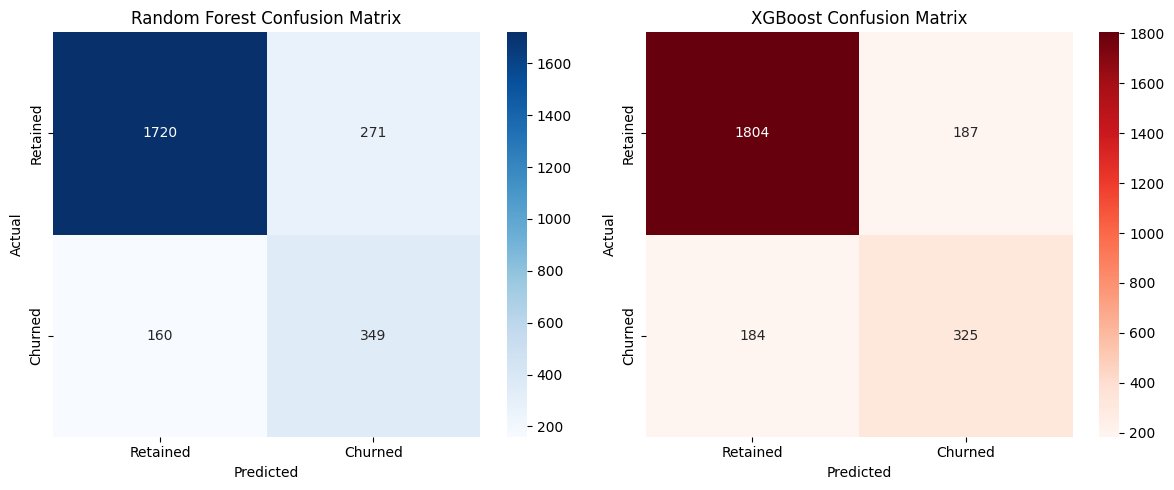

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('member2_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


SHAP ANALYSIS FOR XGBOOST

SHAP INTERPRETABILITY ANALYSIS
SHAP values calculated successfully


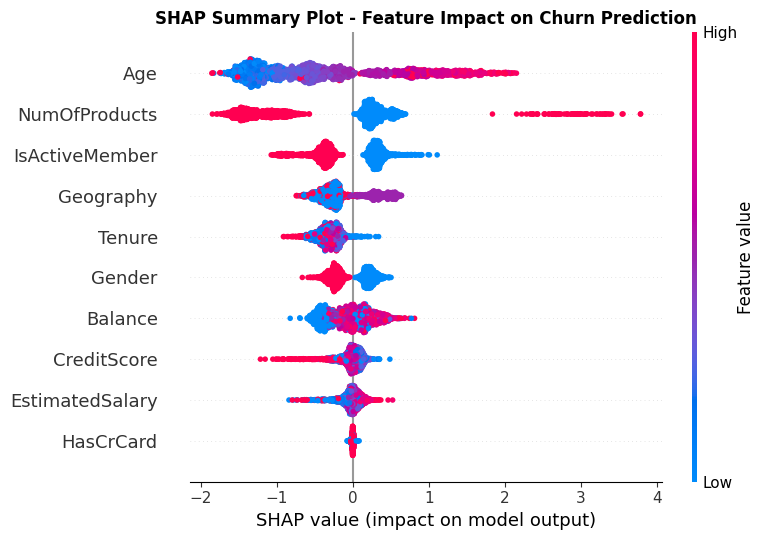

In [ ]:
print("SHAP INTERPRETABILITY ANALYSIS")
print("=" * 60)

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values calculated successfully")

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Summary Plot - Feature Impact on Churn Prediction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('member2_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

SHAP BAR PLOT - GLOBAL IMPORTANCE

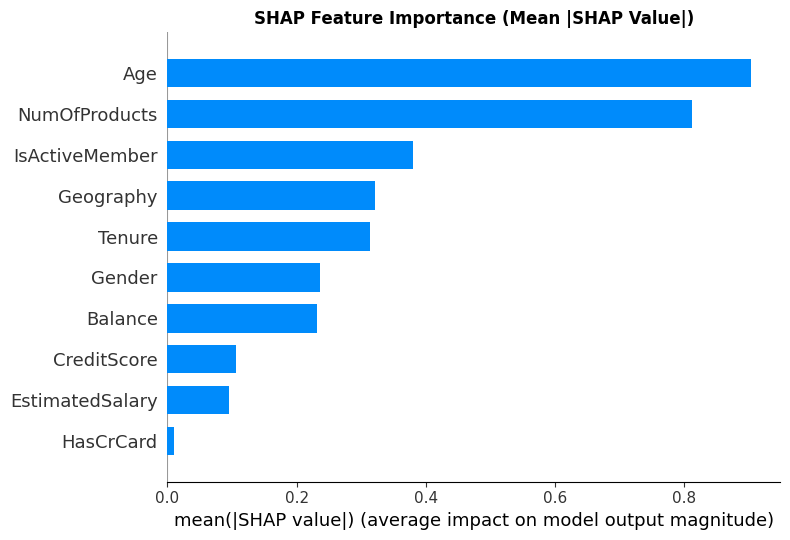

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist(),
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('member2_shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

SHAP INDIVIDUAL PREDICTION EXPLANATION


Explaining prediction for customer at index 3148:
Actual: Retained
Predicted: Retained
Churn Probability: 0.1248


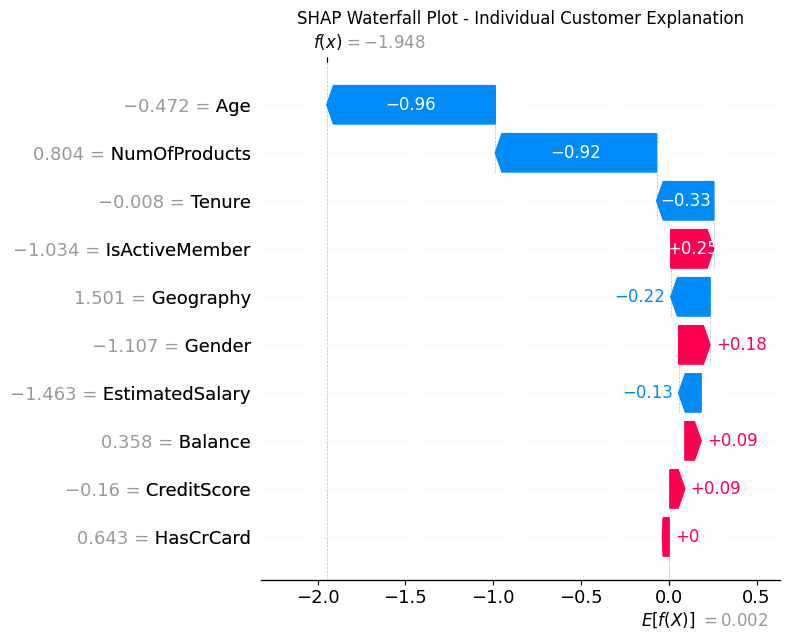

In [ ]:
churned_indices = y_test[y_test == 1].index.tolist()
if len(churned_indices) > 0:
    sample_idx = 0  # First churned customer in test set

    print(f"\nExplaining prediction for customer at index {churned_indices[sample_idx]}:")
    print(f"Actual: {'Churned' if y_test.iloc[sample_idx] == 1 else 'Retained'}")
    print(f"Predicted: {'Churned' if xgb_pred[sample_idx] == 1 else 'Retained'}")
    print(f"Churn Probability: {xgb_prob[sample_idx]:.4f}")

    # Waterfall plot for single prediction
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx],
                                          base_values=explainer.expected_value,
                                          data=X_test_scaled.iloc[sample_idx],
                                          feature_names=X.columns.tolist()), show=False)
    plt.title('SHAP Waterfall Plot - Individual Customer Explanation')
    plt.tight_layout()
    plt.savefig('member2_shap_waterfall.png', dpi=300, bbox_inches='tight')
    plt.show()

CROSS-VALIDATION RESULTS

In [ ]:
print("5-FOLD CROSS-VALIDATION")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest CV
rf_cv_scores = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc')
print(f"\nRandom Forest CV ROC-AUC: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")

# XGBoost CV
xgb_cv_scores = cross_val_score(xgb_model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc')
print(f"XGBoost CV ROC-AUC: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std()*2:.4f})")


5-FOLD CROSS-VALIDATION

Random Forest CV ROC-AUC: 0.9330 (+/- 0.0085)
XGBoost CV ROC-AUC: 0.9537 (+/- 0.0050)


FINAL SUMMARY AND INSIGHTS

In [ ]:
print("MEMBER 2 - CUSTOMER CHURN PREDICTION SUMMARY")
print("=" * 60)

print(f"""
DATASET INFORMATION:
- Dataset: Bank Customer Churn
- Total Samples: {len(churn_df)}
- Features: {len(X.columns)}
- Training Samples: {len(X_train)} (after SMOTE: {len(X_train_smote)})
- Testing Samples: {len(X_test)}
- Original Churn Rate: {churn_df['Exited'].mean()*100:.2f}%

MODEL PERFORMANCE:
+------------------+----------+-----------+--------+----------+---------+
| Model            | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
+------------------+----------+-----------+--------+----------+---------+
| Random Forest    | {accuracy_score(y_test, rf_pred):.4f}   | {precision_score(y_test, rf_pred):.4f}    | {recall_score(y_test, rf_pred):.4f} | {f1_score(y_test, rf_pred):.4f}   | {roc_auc_score(y_test, rf_prob):.4f}  |
| XGBoost          | {accuracy_score(y_test, xgb_pred):.4f}   | {precision_score(y_test, xgb_pred):.4f}    | {recall_score(y_test, xgb_pred):.4f} | {f1_score(y_test, xgb_pred):.4f}   | {roc_auc_score(y_test, xgb_prob):.4f}  |
+------------------+----------+-----------+--------+----------+---------+

BEST MODEL: {best_model} (by ROC-AUC)

TOP 5 CHURN PREDICTORS (from SHAP):
""")

# Print top 5 features from SHAP
shap_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

for i, row in shap_importance.head(5).iterrows():
    print(f"  {shap_importance.index.get_loc(i)+1}. {row['Feature']}: {row['Mean_SHAP']:.4f}")

member2_results = {
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, rf_pred),
        'Precision': precision_score(y_test, rf_pred),
        'Recall': recall_score(y_test, rf_pred),
        'F1': f1_score(y_test, rf_pred),
        'AUC': roc_auc_score(y_test, rf_prob),
        'Kappa': cohen_kappa_score(y_test, rf_pred)
    },
    'XGBoost': {
        'Accuracy': accuracy_score(y_test, xgb_pred),
        'Precision': precision_score(y_test, xgb_pred),
        'Recall': recall_score(y_test, xgb_pred),
        'F1': f1_score(y_test, xgb_pred),
        'AUC': roc_auc_score(y_test, xgb_prob),
        'Kappa': cohen_kappa_score(y_test, xgb_pred)
    }
}

print("Member 2 Results Stored:")
print("-" * 40)
for model, metrics in member2_results.items():
    print(f"\n{model}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")



MEMBER 2 - CUSTOMER CHURN PREDICTION SUMMARY

DATASET INFORMATION:
- Dataset: Bank Customer Churn
- Total Samples: 10000
- Features: 10
- Training Samples: 7500 (after SMOTE: 11944)
- Testing Samples: 2500
- Original Churn Rate: 20.37%

MODEL PERFORMANCE:
+------------------+----------+-----------+--------+----------+---------+
| Model            | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
+------------------+----------+-----------+--------+----------+---------+
| Random Forest    | 0.8276   | 0.5629    | 0.6857 | 0.6182   | 0.8648  |
| XGBoost          | 0.8516   | 0.6348    | 0.6385 | 0.6366   | 0.8714  |
+------------------+----------+-----------+--------+----------+---------+

BEST MODEL: XGBoost (by ROC-AUC)

TOP 5 CHURN PREDICTORS (from SHAP):

  1. Age: 0.9028
  2. NumOfProducts: 0.8117
  3. IsActiveMember: 0.3803
  4. Geography: 0.3210
  5. Tenure: 0.3134
Member 2 Results Stored:
----------------------------------------

Random Forest:
  Accuracy: 0.8276
  Precision:

comparions


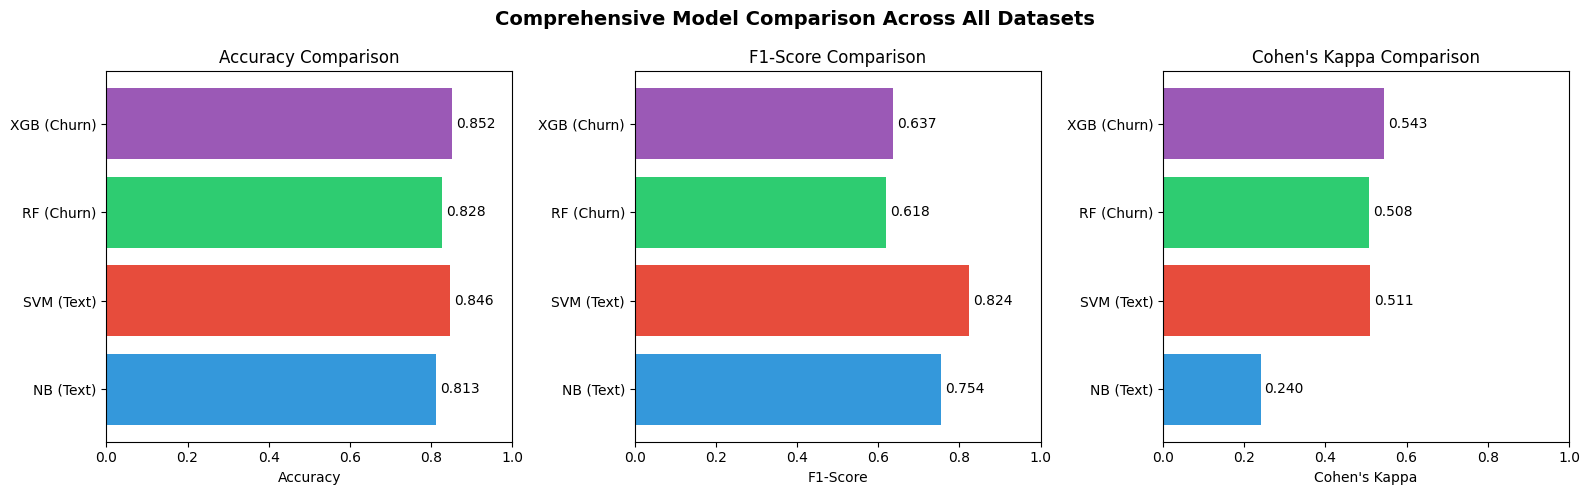

In [ ]:
print("comparions")

import numpy as np
import matplotlib.pyplot as plt

# Member 1 - Sentiment Analysis
nb_acc, nb_f1, nb_kappa = 0.81296, 0.753952, 0.240271
svm_acc, svm_f1, svm_kappa = 0.84560, 0.824156, 0.510589

# Member 2 - Churn Prediction
rf_acc, rf_f1, rf_kappa = 0.8276, 0.618246, 0.508292
xgb_acc, xgb_f1, xgb_kappa = 0.8516, 0.636631, 0.543392

# Data
all_models = ['NB (Text)', 'SVM (Text)', 'RF (Churn)', 'XGB (Churn)']
all_accuracy = [nb_acc, svm_acc, rf_acc, xgb_acc]
all_f1 = [nb_f1, svm_f1, rf_f1, xgb_f1]
all_kappa = [nb_kappa, svm_kappa, rf_kappa, xgb_kappa]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comprehensive Model Comparison Across All Datasets', fontsize=14, fontweight='bold')

for ax, data, xlabel, title in zip(axes,
                                    [all_accuracy, all_f1, all_kappa],
                                    ['Accuracy', 'F1-Score', "Cohen's Kappa"],
                                    ['Accuracy Comparison', 'F1-Score Comparison', "Cohen's Kappa Comparison"]):
    bars = ax.barh(all_models, data, color=colors)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, data):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.savefig('group_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()